In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Bandit:
    def __init__(self, arms=10):
        self.rates = np.random.rand(arms)

    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0


class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)


881


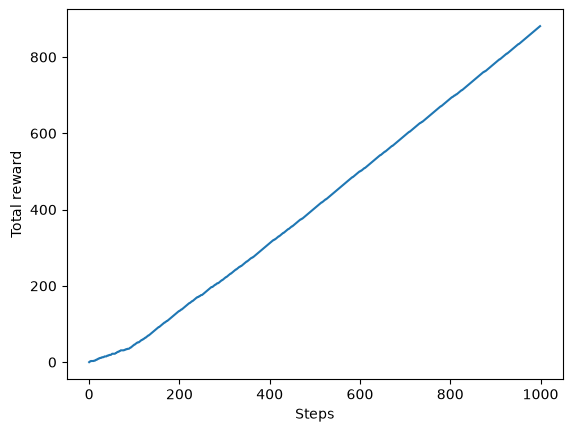

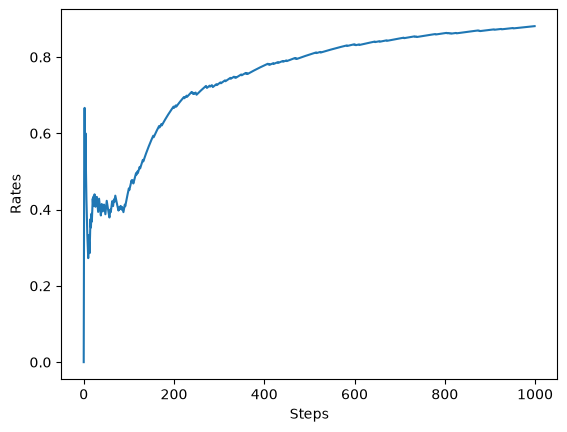

In [ ]:

steps = 1000
epsilon = 0.1
bandit = Bandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = []

rates = []

for step in range(steps):

    # ① 행동 선택
    action = agent.get_action()
   
    # ② 선택한 슬롯머신에서 보상 받기
    reward = bandit.play(action)

    # ③ 행동가치 Q 업데이트
    agent.update(action, reward)

    # ④ 누적 보상 계산
    total_reward += reward
    total_rewards.append(total_reward)
    rates.append(total_reward / (step + 1))

print(total_reward)

# 누적 보상 그래프

plt.plot(total_rewards)
plt.xlabel('Steps')
plt.ylabel('Total reward')

plt.show()

# 승률 그래프

plt.plot(rates)
plt.xlabel('Steps')
plt.ylabel('Rates')
plt.show()